In [1]:
print("Hello World")

Hello World


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import sklearn as sks
import jupyter as jp

In [4]:
cat=np.array([1,2,3])
cat[0]

np.int64(1)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, 
                              classification_report, RocCurveDisplay,
                              PrecisionRecallDisplay)

print("All imports successful!")

All imports successful!


In [6]:
# Load AAC features
enz_aac = pd.read_csv(r"C:\Users\Divya\OneDrive\사진\Desktop\Protein_classifier\features\enzymes_AAC.csv", 
                       sep='\t', index_col=0)
non_aac = pd.read_csv(r"C:\Users\Divya\OneDrive\사진\Desktop\Protein_classifier\features\non_enzymes_AAC.csv", 
                       sep='\t', index_col=0)

print("Enzyme AAC shape:", enz_aac.shape)
print("Non-enzyme AAC shape:", non_aac.shape)
print("\nFirst few rows of enzyme AAC:")
enz_aac.head()

Enzyme AAC shape: (891, 20)
Non-enzyme AAC shape: (2437, 20)

First few rows of enzyme AAC:


,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
#,,,,,,,,,,,,,,,,,,,,
sp|A0A087WWS6|IFNAD_HUMAN,0.068421,0.036842,0.057895,0.078947,0.047368,0.021053,0.015789,0.036842,0.047368,0.142105,0.047368,0.031579,0.036842,0.052632,0.063158,0.094737,0.047368,0.042105,0.010526,0.021053
sp|A0AVT1|UBA6_HUMAN,0.068441,0.021863,0.056084,0.073194,0.051331,0.051331,0.029468,0.063688,0.072243,0.097909,0.017110,0.040875,0.053232,0.038023,0.034221,0.067490,0.066540,0.061787,0.011407,0.023764
sp|A0PJE2|DHR12_HUMAN,0.088328,0.009464,0.044164,0.069401,0.044164,0.078864,0.034700,0.047319,0.053628,0.091483,0.022082,0.037855,0.047319,0.053628,0.056782,0.063091,0.056782,0.069401,0.015773,0.015773
sp|A1L0T0|HACL2_HUMAN,0.115506,0.017405,0.044304,0.044304,0.037975,0.091772,0.023734,0.031646,0.033228,0.125000,0.018987,0.026899,0.058544,0.047468,0.061709,0.045886,0.041139,0.107595,0.012658,0.014241
sp|A6NCW0|U17L3_HUMAN,0.077358,0.035849,0.047170,0.058491,0.024528,0.054717,0.049057,0.024528,0.060377,0.109434,0.022642,0.033962,0.047170,0.073585,0.049057,0.079245,0.056604,0.052830,0.013208,0.030189


In [7]:
# Add labels
enz_aac['label'] = 1      # enzyme = 1
non_aac['label'] = 0      # non-enzyme = 0

# Subsample non-enzymes to match enzyme count
non_aac_sampled = non_aac.sample(n=891, random_state=42)

# Combine into one dataframe
df_aac = pd.concat([enz_aac, non_aac_sampled], axis=0).reset_index(drop=True)

print("Combined dataset shape:", df_aac.shape)
print("\nClass distribution:")
print(df_aac['label'].value_counts())


Combined dataset shape: (1782, 21)

Class distribution:
label
1    891
0    891
Name: count, dtype: int64


In [8]:
enz_dpc = pd.read_csv(r"C:\Users\Divya\OneDrive\사진\Desktop\Protein_classifier\features\enzymes_DPC.csv", 
                       sep='\t', index_col=0)
non_dpc = pd.read_csv(r"C:\Users\Divya\OneDrive\사진\Desktop\Protein_classifier\features\non_enzymes_DPC.csv", 
                       sep='\t', index_col=0)

print("Enzyme DPC shape:", enz_dpc.shape)
print("Non-enzyme DPC shape:", non_dpc.shape)

Enzyme DPC shape: (891, 400)
Non-enzyme DPC shape: (2437, 400)


In [9]:
enz_dpc=pd.read_csv(r"C:\Users\Divya\OneDrive\사진\Desktop\Protein_classifier\features\enzymes_DPC.csv", sep='\t', index_col=0)
non_dpc=pd.read_csv(r"C:\Users\Divya\OneDrive\사진\Desktop\Protein_classifier\features\non_enzymes_DPC.csv", sep='\t', index_col=0)
print("Enzyme DPC shape:", enz_dpc.shape)
print("Non-enzyme DPC shape:", non_dpc.shape)

Enzyme DPC shape: (891, 400)
Non-enzyme DPC shape: (2437, 400)


In [10]:
enz_dpc['label'] = 1
non_dpc['label'] = 0
non_dpc_sampled = non_dpc.sample(n=891, random_state=42)
df_dpc = pd.concat([enz_dpc, non_dpc_sampled], axis=0).reset_index(drop=True)

print("Combined DPC shape:", df_dpc.shape)  # should be (1782, 401)

Combined DPC shape: (1782, 401)


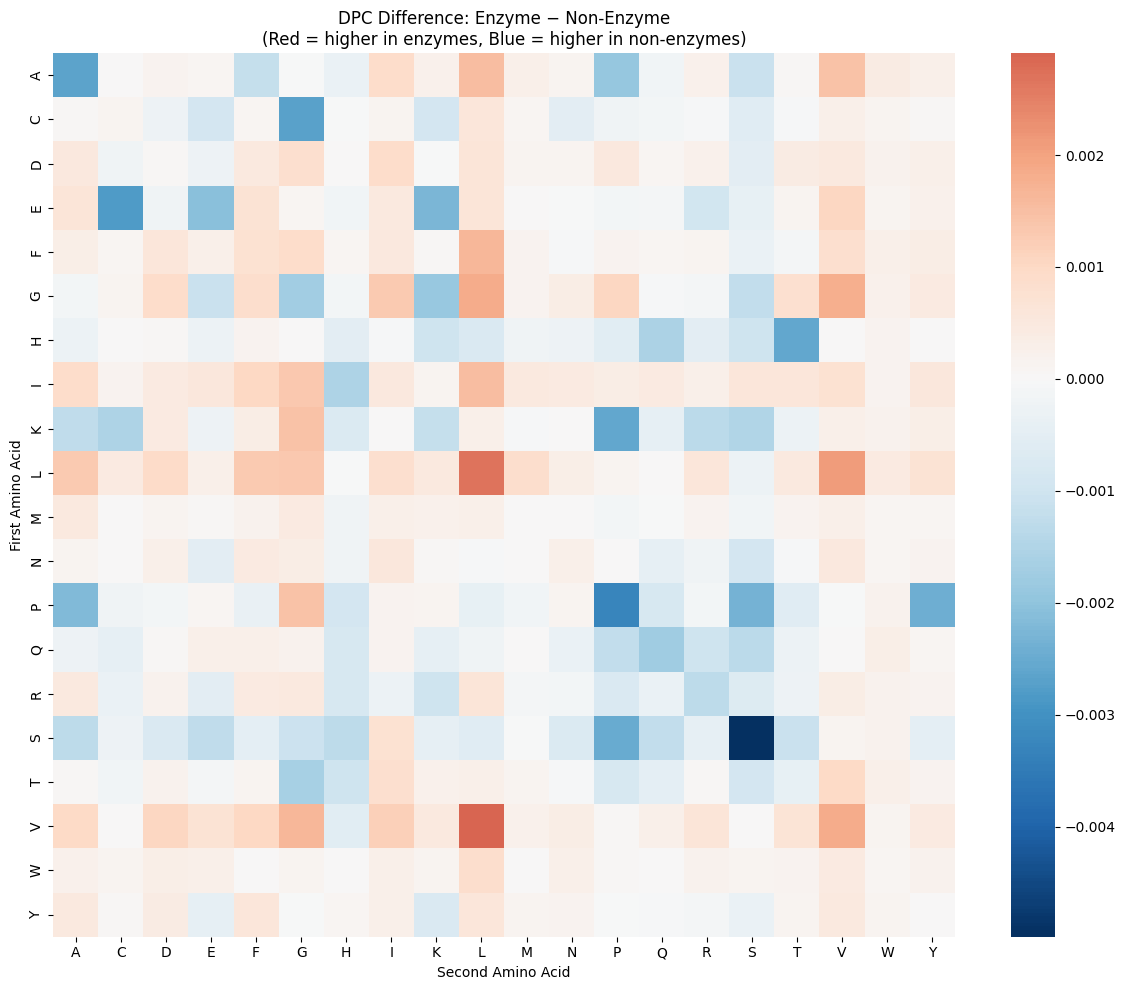

In [11]:
dpc_cols=[col for col in df_dpc.columns if col!='label']
enzyme_dpc_mean=df_dpc[df_dpc['label']==1][dpc_cols].mean()
non_enzyme_dpc_mean=df_dpc[df_dpc['label']==0][dpc_cols].mean()

diff= (enzyme_dpc_mean-non_enzyme_dpc_mean).values.reshape(20, 20)
aa_order=sorted(set(c[0] for c in dpc_cols))

fig, ax=plt.subplots(figsize=(12, 10))
sns.heatmap(diff, xticklabels=aa_order, yticklabels=aa_order, cmap='RdBu_r', center=0, ax=ax)
ax.set_title('DPC Difference: Enzyme − Non-Enzyme\n(Red = higher in enzymes, Blue = higher in non-enzymes)')
ax.set_xlabel('Second Amino Acid')
ax.set_ylabel('First Amino Acid')
plt.tight_layout()
plt.show()

In [13]:
X=df_aac.drop('label', axis=1).values
Y=df_aac['label'].values
X_train, X_test, Y_train, Y_test=train_test_split(X, Y , test_size=0.2, random_state=42, stratify=Y)


scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


print(f"Train size: {X_train_scaled.shape}")
print(f"Test size: {X_test_scaled.shape}")


Train size: (1425, 20)
Test size: (357, 20)


In [14]:
models={'LogisticRegression': LogisticRegression(max_iter=1000),
        'SVM(RBF)': SVC(kernel='rbf', probability=True),
        'Random Forest':RandomForestClassifier(n_estimators=100, random_state=42)}

trained_models={}
for name, model in models.items():
    model.fit(X_train_scaled, Y_train)
    trained_models[name]=model
    print(f"✅ {name} trained")



✅ LogisticRegression trained
✅ SVM(RBF) trained
✅ Random Forest trained


In [19]:
results = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(Y_test, y_pred), 4),
        'AUC_ROC': round(roc_auc_score(Y_test, y_prob), 4)
    })
    print(f"\n--- {name} ---")
    print(classification_report(Y_test, y_pred, target_names=['Non-Enzyme', 'Enzyme']))

results_df = pd.DataFrame(results)
print("\n", results_df)


--- LogisticRegression ---
              precision    recall  f1-score   support

  Non-Enzyme       0.75      0.74      0.75       179
      Enzyme       0.74      0.75      0.75       178

    accuracy                           0.75       357
   macro avg       0.75      0.75      0.75       357
weighted avg       0.75      0.75      0.75       357


--- SVM(RBF) ---
              precision    recall  f1-score   support

  Non-Enzyme       0.79      0.75      0.77       179
      Enzyme       0.76      0.80      0.78       178

    accuracy                           0.78       357
   macro avg       0.78      0.78      0.78       357
weighted avg       0.78      0.78      0.78       357


--- Random Forest ---
              precision    recall  f1-score   support

  Non-Enzyme       0.80      0.75      0.77       179
      Enzyme       0.76      0.81      0.79       178

    accuracy                           0.78       357
   macro avg       0.78      0.78      0.78       357
weigh

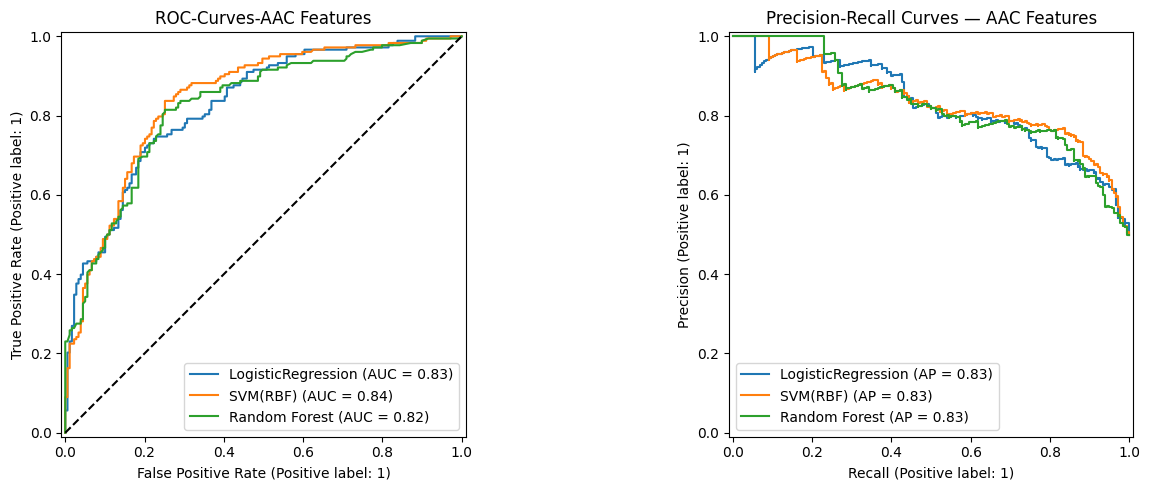

In [22]:
fig, axes=plt.subplots(1,2,figsize=(14,5))

for name, model in trained_models.items():
    RocCurveDisplay.from_estimator(model, X_test_scaled, Y_test, ax=axes[0], name=name)
axes[0].set_title('ROC-Curves-AAC Features')
axes[0].plot([0,1],[0,1],'k--', label='Random')

for name, model in trained_models.items():
    PrecisionRecallDisplay.from_estimator(model, X_test_scaled, Y_test, ax=axes[1], name=name)

axes[1].set_title('Precision-Recall Curves — AAC Features')
plt.tight_layout()
plt.show()

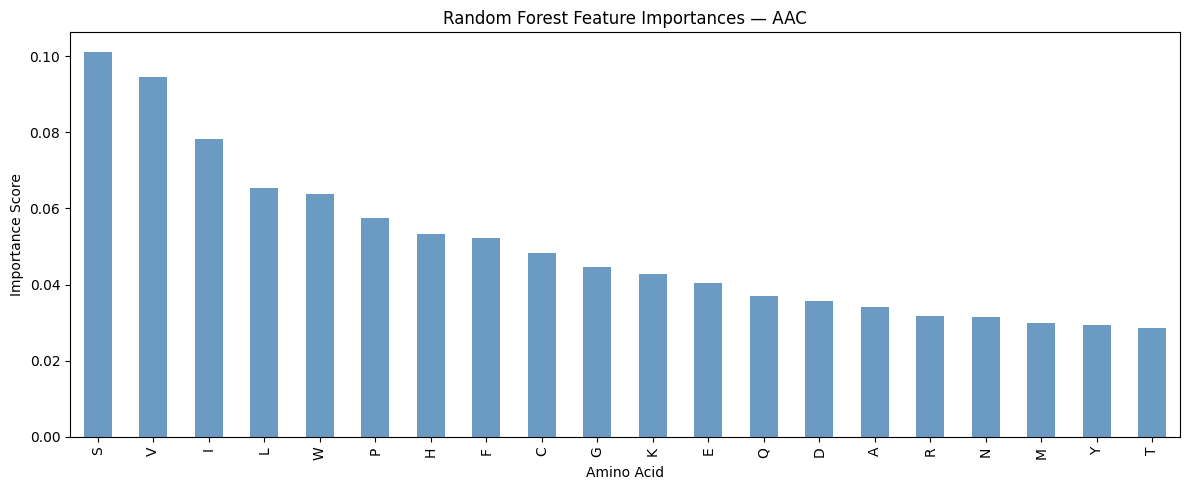


Top 5 most important amino acids:
S    0.101172
V    0.094445
I    0.078139
L    0.065385
W    0.063665
dtype: float64


In [23]:
rf = trained_models['Random Forest']
aac_cols = [col for col in df_aac.columns if col != 'label']
importances = pd.Series(rf.feature_importances_, index=aac_cols).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
importances.plot(kind='bar', color='steelblue', alpha=0.8)
plt.title('Random Forest Feature Importances — AAC')
plt.xlabel('Amino Acid')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 most important amino acids:")
print(importances.head())


In [24]:
X_dpc = df_dpc.drop('label', axis=1).values
y_dpc = df_dpc['label'].values

X_train_dpc, X_test_dpc, y_train_dpc, y_test_dpc = train_test_split(
    X_dpc, y_dpc, test_size=0.2, random_state=42, stratify=y_dpc
)

scaler_dpc = StandardScaler()
X_train_dpc_scaled = scaler_dpc.fit_transform(X_train_dpc)
X_test_dpc_scaled = scaler_dpc.transform(X_test_dpc)

for name, model in models.items():
    model.fit(X_train_dpc_scaled, y_train_dpc)
    y_pred = model.predict(X_test_dpc_scaled)
    y_prob = model.predict_proba(X_test_dpc_scaled)[:, 1]
    acc = round(accuracy_score(y_test_dpc, y_pred), 4)
    auc = round(roc_auc_score(y_test_dpc, y_prob), 4)
    print(f"{name}: Accuracy={acc}, AUC={auc}")

LogisticRegression: Accuracy=0.7339, AUC=0.8083
SVM(RBF): Accuracy=0.7815, AUC=0.8533
Random Forest: Accuracy=0.7871, AUC=0.8314
